![header](https://i.imgur.com/I4ake6d.jpg)


# COPERNICUS MARINE SERVICE : Arctic Ocean

<div style="text-align: right"><i> Lesson 1 of 3 - Copernicus Marine Toolbox </i></div>

***
<center><h1> Arctic sea ice from space: downloading original files with get </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>
<br>
**General Note 3**: Exercises are shown in yellow boxes. Write your answer in the empty cell below each exercise. If you are stuck, a solution can be loaded from the `_solved` folder.<br>
***

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Checking the environment](#2.2-Checking-the-environment)
- [3. The Copernicus Marine Data Store and Help Center](#3.-The-Copernicus-Marine-Data-Store-and-Help-Center)
    - [3.1 The Help Center](#3.1-The-Help-Center)
    - [3.2 Finding a product in the Data Store](#3.2-Finding-a-product-in-the-Data-Store)
    - [3.3 The product page](#3.3-The-product-page)
    - [3.4 Data access and the File Browser](#3.4-Data-access-and-the-File-Browser)
    - [3.5 Presentation of the product used](#3.5-Presentation-of-the-product-used)
- [4. Downloading original files with get](#4.-Downloading-original-files-with-get)
    - [4.1 Logging in](#4.1-Logging-in)
    - [4.2 Checking a download before running it](#4.2-Checking-a-download-before-running-it)
    - [4.3 Exploring the object returned by get](#4.3-Exploring-the-object-returned-by-get)
    - [4.4 Selecting and downloading files](#4.4-Selecting-and-downloading-files)
- [5. First look at the data with xarray](#5.-First-look-at-the-data-with-xarray)
    - [5.1 Opening the file](#5.1-Opening-the-file)
    - [5.2 Surface temperature](#5.2-Surface-temperature)
    - [5.3 Sea ice fraction](#5.3-Sea-ice-fraction)
- [6. Exercises to go further](#6.-Exercises-to-go-further)
- [7. Conclusion](#7.-Conclusion)

---
# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The Arctic Ocean is covered by sea ice that grows every winter and melts every summer. Each year, the ice reaches its largest extent in March, at the end of winter, and its smallest extent in September, at the end of summer. In 2025, satellites recorded the **lowest winter maximum since observations began**, on 22 March ([NSIDC news release](https://nsidc.org/news-analyses/news-stories/arctic-sea-ice-hits-record-low-maximum-extent-year)), while the summer minimum, on 10 September, was among the ten lowest on record ([NSIDC news release](https://nsidc.org/ru/node/431291)). Monitoring these changes matters for climate science, but also for shipping routes, fisheries and Arctic communities.

Satellites observe the Arctic every day, and the Copernicus Marine Service distributes these observations for free. In this notebook, we will use them to compare the Arctic at the end of summer and at the end of winter.

| | |
| :--- | :--- |
| **Objective** | Learn how to find a product on the Copernicus Marine Data Store and download its **original files** with the `get` function of the Copernicus Marine Toolbox. |
| **Main question** | What did the Arctic surface look like, seen from space, at the 2025 sea ice minimum and maximum? |
| **Expected outcomes** | You will be able to check a download before running it, select files by name, download them, explore the object returned by the Toolbox, and open and map the data with xarray. |
| **Duration** | About 30 minutes |
| **Prerequisites** | A free [Copernicus Marine account](https://data.marine.copernicus.eu/register) and basic Python knowledge |

This notebook is the first of a series of three. The next ones present the `subset` function, then the `open_dataset` and `read_dataframe` functions. Each notebook can be followed on its own.

---
# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules

[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this notebook.

| Module name | Description |
| :---: | :---|
| **copernicusmarine** | The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) gives access to the Copernicus Marine catalogue and data from Python or from the command line. |
| **xarray** | [Xarray](https://docs.xarray.dev/en/stable/) is a very user-friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** | [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data in Python. |
| **pathlib** | [Pathlib](https://docs.python.org/3/library/pathlib.html) handles file paths in the same way on every operating system. |

We also import a small plotting function, `plot_arctic_map`, stored in the `utils` folder. It draws a map centred on the North Pole, so that the map code is not repeated in every cell. You can open `utils/arctic_maps.py` to see how it works.

In [1]:
# To avoid warning messages
import warnings
warnings.filterwarnings("ignore")

# Import libraries
from importlib.metadata import version
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

from utils.arctic_maps import plot_arctic_map

## 2.2 Checking the environment

[Go back to the "Table of contents"](#Table-of-contents)

Let's check the versions of the main packages. This notebook was written for **version 2.5.0** of the Copernicus Marine Toolbox: if your version is older, see the [installation guide](https://help.marine.copernicus.eu/en/articles/7970514-copernicus-marine-toolbox-installation) to update it.

In [3]:
for package in ["copernicusmarine", "xarray", "matplotlib", "cartopy"]:
    print(f"{package:<18} {version(package)}")

copernicusmarine   2.5.0b0
xarray             2026.7.0
matplotlib         3.11.1
cartopy            0.25.0


We also create the folder where the downloaded files will be stored:

In [4]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)
print(f"Files will be downloaded to: {data_directory.resolve()}")

Files will be downloaded to: /homelocal/gkoenig/Downloads/training-Arctic/data


## 2.3 Copernicus Marine Toolbox
[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) is a library that gives access to the Copernicus Marine data from Python code or from the command line. Its `get` function downloads **original files**: the files exactly as they were delivered by the data producer, without any modification. This is the right choice when you need whole files, for example to use them with the producer's own software or to build a complete archive.

First, we import the Toolbox:

In [5]:
import copernicusmarine

And then we have to log in.

The **login** function asks for the username and password of your Copernicus Marine account. It saves them in a configuration file, so that you do not need to enter them again in the next cells, or in the next notebooks of this training.

If you do not have an account yet, you can create one for free on the [registration page](https://data.marine.copernicus.eu/register).

In [ ]:
copernicusmarine.login()

> 📖 **Learn more in the Help Center:** [Toolbox credentials configuration](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration)

---
# 3. The Copernicus Marine Data Store and Help Center

[Go back to the "Table of contents"](#Table-of-contents)

Before writing any code, we need to know **which data we want** and **where to find them**. The Copernicus Marine Service offers two websites for this: the **Data Store**, to browse and access the products, and the **Help Center**, to learn how to use them.

## 3.1 The Help Center

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Help Center](https://help.marine.copernicus.eu/) is the place to find answers to your questions about the Copernicus Marine products and tools: how to choose a product, how to install and use the Toolbox, how to read the data, and what to do when something goes wrong. Throughout this notebook, the 📖 boxes point to the Help Center articles that go deeper into each topic. A good place to start is the article [How to access and download Copernicus Marine data](https://help.marine.copernicus.eu/en/articles/16733110-how-to-access-and-download-copernicus-marine-data).

If you cannot find an answer there, you can contact the service desk at [servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu).

## 3.2 Finding a product in the Data Store

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Data Store](https://data.marine.copernicus.eu/products) lists all the products of the service. To find the one you need, you can:

- use the **filters** at the top of the page: "Variables", "Areas" and "Time range", or click "Advanced" for more criteria such as "Source" (model, satellite or in situ) or "Processing level"
- or type a **product name, product ID or variable** in the search bar

For this notebook, select the area "Arctic Ocean" and the source "Satellite observations", or type the product ID `SEAICE_ARC_SEAICE_L4_NRT_OBSERVATIONS_011_008` in the search bar.

| <img src="img/01_data_store_search.png" width="800"> |
|:--:|
| Searching for Arctic satellite products in the Copernicus Marine Data Store. |

> 📖 **Learn more in the Help Center:** [How to search for a product within the Data Store](https://help.marine.copernicus.eu/en/articles/4425061-how-to-search-for-a-product-within-the-copernicus-marine-data-store) · [How to select the best product for your needs](https://help.marine.copernicus.eu/en/articles/16197361-how-to-select-the-best-copernicus-marine-product-for-your-needs)

## 3.3 The product page

[Go back to the "Table of contents"](#Table-of-contents)

Click on a product to open its page. The menu of the page gives access to several sections:

- **Description**: an overview of the product, its use cases and a "Classification" table with its main characteristics (resolution, coverage, variables, processing level...)
- **Data access**: the list of the datasets in the product, and the services to download them
- **Documentation**: the **Product User Manual (PUM)**, which explains how the product is made and how its files are organised, and the **QUality Information Document (QUID)**, which describes its accuracy
- **DOI**: the reference to use when you cite the product in a publication

A **product** can contain several **datasets**: for example, the same variables at daily and monthly resolution. The Toolbox always works with a **dataset ID**, which you can copy from the "Data access" section of the product page.

| <img src="img/01_product_page.png" width="800"> |
|:--:|
| The page of the product used in this notebook. |

> 📖 **Learn more in the Help Center:** [Introduction to the Data Store](https://help.marine.copernicus.eu/en/articles/6722477-introduction-to-the-copernicus-marine-data-store) · [Products, datasets and their identifiers](https://help.marine.copernicus.eu/en/articles/4703373-differences-between-copernicus-marine-products-and-datasets-and-their-identifiers) · [What is in the PUM?](https://help.marine.copernicus.eu/en/articles/4425095-what-kind-of-information-can-be-found-in-the-pum) · [What is in the QUID?](https://help.marine.copernicus.eu/en/articles/6588555-what-kind-of-information-can-be-found-in-the-quid)

## 3.4 Data access and the File Browser

[Go back to the "Table of contents"](#Table-of-contents)

The "Data access" section offers three services for each dataset:

- **Subsetter (Form)**: select an area, a period and variables, and download only this part of the data. This is what the `subset` function of the Toolbox does (see the next notebook).
- **File Browser (Browse)**: browse and download the **original files**, exactly as delivered by the producer of the data. This is what the `get` function of the Toolbox does.
- **WMTS**: display the data as map tiles in other applications.

Open the File Browser of our dataset: you will see that the files are organised in folders by year and month, with **one file per day**. Look at the names of the files: they start with the date. We will use this to select files with the Toolbox.

| <img src="img/01_file_browser.png" width="800"> |
|:--:|
| The File Browser shows the original files, organised by year and month. |

The File Browser is convenient for a few files. The Toolbox becomes useful as soon as you need many files, want to automate your downloads, or want to process the data directly in Python.

> 📖 **Learn more in the Help Center:** [Introduction to the File Browser](https://help.marine.copernicus.eu/en/articles/8006209-introduction-to-the-file-browser) · [Differences between original files and ARCO data](https://help.marine.copernicus.eu/en/articles/8656000-differences-between-original-producer-files-and-arco-data)

## 3.5 Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)

In this notebook, we use the product **Arctic Ocean - Sea and Ice Surface Temperature**, produced by the Danish Meteorological Institute (DMI). It combines infrared satellite observations into a daily, gap-free map (processing level L4) of the surface temperature of the ocean, the sea ice and the marginal ice zone. Each file also contains the **sea ice fraction** used in the analysis.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [SEAICE_ARC_SEAICE_L4_NRT_OBSERVATIONS_011_008](https://data.marine.copernicus.eu/product/SEAICE_ARC_SEAICE_L4_NRT_OBSERVATIONS_011_008/description) |
| **Dataset ID** | DMI-ARC-SEAICE_TEMP-L4-NRT-OBS |
| **Source** | Satellite observations, processing level L4 |
| **Spatial resolution** | 0.05° (about 5 km) |
| **Spatial coverage** | Arctic, north of 58°N |
| **Temporal resolution** | Daily, one file per day |
| **Temporal coverage** | From 2018 to a few days ago (near real time) |
| **Variables used** | analysed_st (surface temperature, in kelvin), sea_ice_fraction (between 0 and 1) |
| **DOI** | [10.48670/moi-00130](https://doi.org/10.48670/moi-00130) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/SEAICE_ARC_SEAICE_L4_NRT_OBSERVATIONS_011_008.jpg" width="400"> |
|:--:|
| Arctic Ocean - Sea and Ice Surface Temperature. - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/SEAICE_ARC_SEAICE_L4_NRT_OBSERVATIONS_011_008/description) |

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-SEAICE-PUM-011-008-022.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-SEAICE-QUID-011-008-022.pdf)

> 📖 **Learn more in the Help Center:** [How to cite Copernicus Marine products](https://help.marine.copernicus.eu/en/articles/4444611-how-to-cite-copernicus-marine-products-and-services)

---
# 4. Downloading original files with get



## 4.1 Checking a download before running it

[Go back to the "Table of contents"](#Table-of-contents)

Original files can be large, and a dataset can contain thousands of them. Before downloading anything, it is good practice to check **what** would be downloaded with the `dry_run` option. It returns the list of files and their sizes, but downloads nothing.

The `get` function only needs the **dataset ID**, which we copied from the "Data access" section of the product page:

In [6]:
dataset_id = "DMI-ARC-SEAICE_TEMP-L4-NRT-OBS"

full_dataset = copernicusmarine.get(dataset_id=dataset_id, dry_run=True)

WARNING - 2026-10-08T09:14:02Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:14:02Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:14:02Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T09:14:03Z - Selected dataset version: "default"
INFO - 2026-10-08T09:14:03Z - Selected dataset part: "default"
INFO - 2026-10-08T09:14:03Z - Listing files on remote server...
4it [00:01,  3.25it/s]
INFO - 2026-10-08T09:14:05Z - Total size of the download: 192.44 GB.


In [7]:
print(f"Number of files: {full_dataset.number_of_files_to_download}")
print(f"Total size: {full_dataset.total_size / 1000:.0f} GB")

Number of files: 3201
Total size: 197 GB


Downloading the whole dataset would take several thousand files and around 200 GB: far too much for a training session, and rarely what you need. We will soon see how to select only the files we want.

<div class="alert alert-block alert-warning">

**Exercise 1**

The same surface temperature is also available as a long-term, reprocessed record in the product **SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016**. Its dataset ID is `cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m`.

Using a dry run, find how many files this dataset contains and how much space they take. Why are there many more files than in the near-real-time dataset?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the cell above and change the dataset ID. Store the result in a new variable, for example `reprocessed_dataset`.
</details>

In [ ]:
# Enter your code here

WARNING - 2026-10-08T09:15:11Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:15:11Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:15:11Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T09:15:12Z - Selected dataset version: "202105"
INFO - 2026-10-08T09:15:12Z - Selected dataset part: "default"
INFO - 2026-10-08T09:15:12Z - Listing files on remote server...
17it [00:04,  3.61it/s]
INFO - 2026-10-08T09:15:17Z - Total size of the download: 174.49 GB.


**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [19]:
# %load _solved/ARCTBX-01-get_exercise-1.py
# Dry run on the reprocessed (multi-year) product: nothing is downloaded
reprocessed_dataset = copernicusmarine.get(
    dataset_id="cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m",
    dry_run=True,
)

print(f"Number of files: {reprocessed_dataset.number_of_files_to_download}")
print(f"Total size: {reprocessed_dataset.total_size / 1000:.0f} GB")


WARNING - 2026-10-08T09:40:22Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:40:22Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T09:40:22Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T09:40:22Z - Selected dataset version: "202105"
INFO - 2026-10-08T09:40:22Z - Selected dataset part: "default"
INFO - 2026-10-08T09:40:23Z - Listing files on remote server...
17it [00:04,  3.48it/s]
INFO - 2026-10-08T09:40:28Z - Total size of the download: 174.49 GB.


Number of files: 16252
Total size: 179 GB


> 📖 **Learn more in the Help Center:** [Toolbox API - Get original files](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files)

## 4.3 Exploring the object returned by get

[Go back to the "Table of contents"](#Table-of-contents)

The `get` function does not only download files: it also returns a Python object describing them. Let's look at its type:

In [11]:
type(full_dataset)

copernicusmarine.core_functions.models.ResponseGet

This `ResponseGet` object has several attributes. You can find a list and description of those [in the documentation of the Copernicus Marine Toolbox](https://toolbox-docs.marine.copernicus.eu/en/stable/response-types.html#copernicusmarine.ResponseGet). 

We have already used `number_of_files_to_download` and `total_size` (in MB). The most useful one is `files`: a list containing one element per file. Let's look at the first file of the dataset:

In [14]:
first_file = full_dataset.files[0]
first_file

FileGet(s3_url='s3://mdl-native-09/native/SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m_202105/1982/01/19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc', https_url='https://s3.waw3-1.cloudferro.com/mdl-native-09/native/SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m_202105/1982/01/19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc', file_size=9.269762992858887, last_modified_datetime='2024-01-15T09:25:16.231000+00:00', etag='"a31dd68b6a790b4bee158eb5c2d9e776"', file_format='.nc', output_directory=PosixPath('.'), filename='19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc', file_path=PosixPath('SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m_202105/1982/01/19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc'), file_status='DOWNLOADED')

Each file has its own attributes, such as its name, its size in MB and the date it was last modified on the server:

In [18]:
print(f"File name:     {first_file.filename}")
print(f"Size:          {first_file.file_size:.1f} MB")
print(f"Last modified: {first_file.last_modified_datetime}")

File name:     19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
Size:          9.3 MB
Last modified: 2024-01-15T09:25:16.231000+00:00


Since `files` is a Python list, we can also loop over it, or look at its last element to see the most recent file available:

In [17]:
print("First 3 files:")
for file in full_dataset.files[:3]:
    print(f"  {file.filename}")

print(f"Most recent file: {full_dataset.files[-1].filename}")

First 3 files:
  19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
  19820102120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
  19820103120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
Most recent file: 20260630120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc


The names confirm what we saw in the File Browser: there is one file per day, and each name **starts with the date and time** of the data, in the format `YYYYMMDDhhmmss`. For example, `20250910120000` means 10 September 2025 at 12:00.

<div class="alert alert-block alert-warning">

**Exercise 2**

Using the dry run of the reprocessed dataset from exercise 1, print the names of its **first** and **last** files, and the size of one file.

Which period does this dataset cover? Do its file names follow the same pattern as the near-real-time dataset?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

The first element of a list is `my_list[0]` and the last one is `my_list[-1]`.
</details>

In [ ]:
# Enter your solution here

'19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc'

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [27]:
# %load _solved/ARCTBX-01-get_exercise-2.py
# The dry run of exercise 1 is repeated here, so that this solution works on its own
reprocessed_dataset = copernicusmarine.get(
    dataset_id="cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m",
    dry_run=True,
)

first_file = reprocessed_dataset.files[0]
last_file = reprocessed_dataset.files[-1]

print(f"First file: {first_file.filename}")
print(f"Last file:  {last_file.filename}")
print(f"Size of one file: {first_file.file_size:.1f} MB")


WARNING - 2026-10-08T12:09:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:09:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:09:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T12:09:32Z - Selected dataset version: "202105"
INFO - 2026-10-08T12:09:32Z - Selected dataset part: "default"
INFO - 2026-10-08T12:09:33Z - Listing files on remote server...
17it [00:03,  4.49it/s]
INFO - 2026-10-08T12:09:37Z - Total size of the download: 174.49 GB.


First file: 19820101120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
Last file:  20260630120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
Size of one file: 9.3 MB


## 4.4 Selecting and downloading files

[Go back to the "Table of contents"](#Table-of-contents)

To select only some files, the `get` function has a `filter` option. It keeps the files whose names match a **pattern**, in which `*` means "any characters". Since the file names start with the date, `"*202509*"` selects all the files of September 2025. Let's check it with a dry run:

In [28]:
september_2025 = copernicusmarine.get(dataset_id=dataset_id, filter="*202509*", dry_run=True)

print(f"Number of files: {september_2025.number_of_files_to_download}")
print(f"Total size: {september_2025.total_size:.0f} MB")

WARNING - 2026-10-08T12:15:58Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:15:58Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:15:58Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T12:15:59Z - Selected dataset version: "202105"
INFO - 2026-10-08T12:15:59Z - Selected dataset part: "default"
INFO - 2026-10-08T12:15:59Z - Listing files on remote server...
17it [00:03,  4.56it/s]
INFO - 2026-10-08T12:16:05Z - Total size of the download: 300.78 MB.


Number of files: 30
Total size: 301 MB


We get 30 files, one for each day of September. To select a single day, we add the day to the pattern. Let's download the file of **10 September 2025**, the day of the 2025 sea ice minimum.

We also use three other options:

- `output_directory` sets where the file is saved
- `no_directories=True` saves the file directly in this folder, instead of reproducing the year and month folders of the server
- `skip_existing=True` does not download the file again if it is already there, which is convenient if you run the cell twice

In [29]:
minimum_response = copernicusmarine.get(
    dataset_id=dataset_id,
    filter="*20250910*",
    output_directory=data_directory,
    no_directories=True,
    skip_existing=True,
)

WARNING - 2026-10-08T12:16:38Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:16:38Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:16:38Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T12:16:39Z - Selected dataset version: "202105"
INFO - 2026-10-08T12:16:39Z - Selected dataset part: "default"
INFO - 2026-10-08T12:16:39Z - Listing files on remote server...
17it [00:03,  4.61it/s]
INFO - 2026-10-08T12:16:45Z - Total size of the download: 9.43 MB.


The returned object tells us where the file was saved, so we never need to type its name. Let's check that the download worked:

In [30]:
print(f"Number of files: {len(minimum_response.files)}")

minimum_file = Path(minimum_response.files[0].file_path)
print(f"File path: {minimum_file}")
print(f"The file exists: {minimum_file.exists()}")

Number of files: 1
File path: data/20250910120000-DMI-L4_GHRSST-STskin-DMI_OI-ARC_IST-v02.0-fv01.0.nc
The file exists: True


<div class="alert alert-block alert-warning">

**Exercise 3**

Download the file of **22 March 2025**, the day of the 2025 sea ice maximum, in the same folder.

Start with a dry run to check that your pattern selects exactly one file, then download it.
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Only the date in the filter needs to change. Use the variables `dataset_id` and `data_directory` defined above.
</details>

In [ ]:
# Enter your solution here

WARNING - 2026-10-08T12:18:09Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:18:09Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T12:18:09Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T12:18:09Z - Selected dataset version: "202105"
INFO - 2026-10-08T12:18:09Z - Selected dataset part: "default"
INFO - 2026-10-08T12:18:09Z - Listing files on remote server...
17it [00:03,  4.68it/s]
INFO - 2026-10-08T12:18:15Z - Total size of the download: 10.59 MB.


**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-01-get_exercise-3.py
# 1. Check the selection with a dry run: we expect exactly one file
maximum_dry_run = copernicusmarine.get(
    dataset_id=dataset_id,
    filter="*20250322*",
    dry_run=True,
)
print(f"Number of files selected: {maximum_dry_run.number_of_files_to_download}")

# 2. Download it
maximum_response = copernicusmarine.get(
    dataset_id=dataset_id,
    filter="*20250322*",
    output_directory=data_directory,
    no_directories=True,
    skip_existing=True,
)

maximum_file = Path(maximum_response.files[0].file_path)
print(f"File downloaded: {maximum_file}")
print(f"The file exists: {maximum_file.exists()}")


> 📖 **Learn more in the Help Center:** [Toolbox API - Get original files (filter, file lists, synchronisation)](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files) · [The same with the command line](https://help.marine.copernicus.eu/en/articles/7983226-copernicus-marine-toolbox-cli-get-original-files)

---
# 5. First look at the data with xarray

[Go back to the "Table of contents"](#Table-of-contents)

The files are in **NetCDF** format. NetCDF (Network Common Data Form) is a file format designed for multi-dimensional scientific data, such as variables that vary with time, latitude and longitude. It is self-describing: each file contains the data and their metadata (units, dimensions, descriptions). We read it with the **xarray** library.

## 5.1 Opening the file

[Go back to the "Table of contents"](#Table-of-contents)

In [35]:
minimum_data = xr.open_dataset(minimum_file)
minimum_data

<xarray.Dataset> Size: 147MB
Dimensions:           (time: 1, lat: 640, lon: 7200)
Coordinates:
  * time              (time) datetime64[ns] 8B 2025-09-10T12:00:00
  * lat               (lat) float32 3kB 58.0 58.05 58.1 ... 89.85 89.9 89.95
  * lon               (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    analysed_st       (time, lat, lon) float32 18MB ...
    analysis_error    (time, lat, lon) float32 18MB ...
    observation_std   (time, lat, lon) float32 18MB ...
    observation_min   (time, lat, lon) float32 18MB ...
    observation_max   (time, lat, lon) float32 18MB ...
    observation_num   (time, lat, lon) float32 18MB ...
    mask              (time, lat, lon) float32 18MB ...
    sea_ice_fraction  (time, lat, lon) float32 18MB ...
Attributes: (12/47)
    Conventions:                CF-1.4, Unidata Observation Dataset v1.0
    title:                      Arctic Sea and Ice Surface Temperature, L4, 5...
    summary:                    DMI Sea and Ice Surface Temperature analysis ...
    references:                 Høyer, J. L. and She, J., Optimal interpolati...
    institution:                Danish Meteorological Institute, DMI
    history:                    Version 1.0
    ...                         ...
    publisher_name:             CMEMS SI TAC and DMI
    publisher_url:              https://marine.copernicus.eu/
    publisher_email:            servicedesk.cmems@mercator-ocean.eu
    processing_level:           L4
    cdm_data_type:              grid
    comment:                    IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES ...

The dataset has **three dimensions**: time (a single day here), latitude and longitude. Click on the arrow next to "Data variables" to see the variables. We will use two of them:

- `analysed_st`: the analysed surface temperature, in kelvin
- `sea_ice_fraction`: the fraction of each grid cell covered by sea ice, between 0 (open water) and 1 (fully covered)

You can click on the 📄 icon next to each variable to see its metadata, such as its units and long name.

Let's select the surface temperature for our single day, and check for missing values. Grid points on land have no value (`NaN`), as the product only covers the ocean and the sea ice:

In [36]:
temperature = minimum_data["analysed_st"].isel(time=0)

missing_points = int(temperature.isnull().sum())
print(f"Missing values: {missing_points} of {temperature.size} grid points ({100 * missing_points / temperature.size:.0f}%)")
print(f"Temperature range: {float(temperature.min()):.1f} K to {float(temperature.max()):.1f} K")

Missing values: 1758592 of 4608000 grid points (38%)
Temperature range: 258.3 K to 292.9 K


## 5.2 Surface temperature

[Go back to the "Table of contents"](#Table-of-contents)

The temperature is in kelvin. To convert it to degrees Celsius, we simply subtract 273.15: xarray applies the operation to every grid point at once.

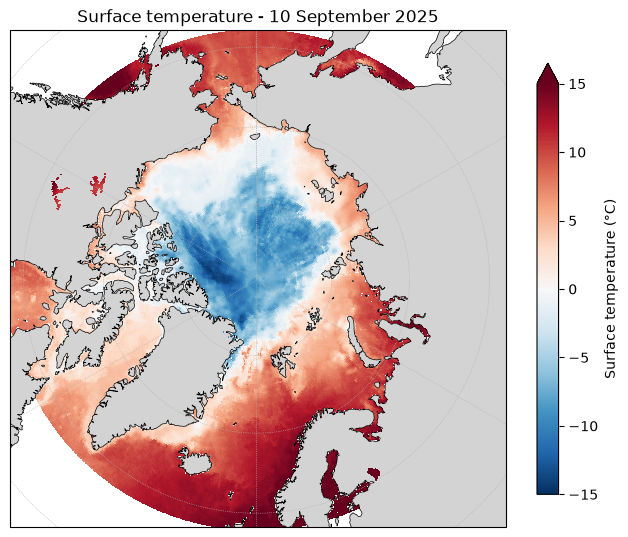

In [40]:
temperature_celsius = temperature - 273.15

plot_arctic_map(
    temperature_celsius,
    "Surface temperature - 10 September 2025",
    cmap="RdBu_r", vmin=-15, vmax=15,
    cbar_kwargs={"label": "Surface temperature (°C)", "shrink": 0.7},
)
plt.show()

At the end of summer, the surface of the ice is close to 0°C or a few degrees below, while the open ocean around it is above 0°C. The colder area in the centre of the Arctic Ocean corresponds to the remaining sea ice.

## 5.3 Sea ice fraction

[Go back to the "Table of contents"](#Table-of-contents)

Let's now map the sea ice fraction for the same day:

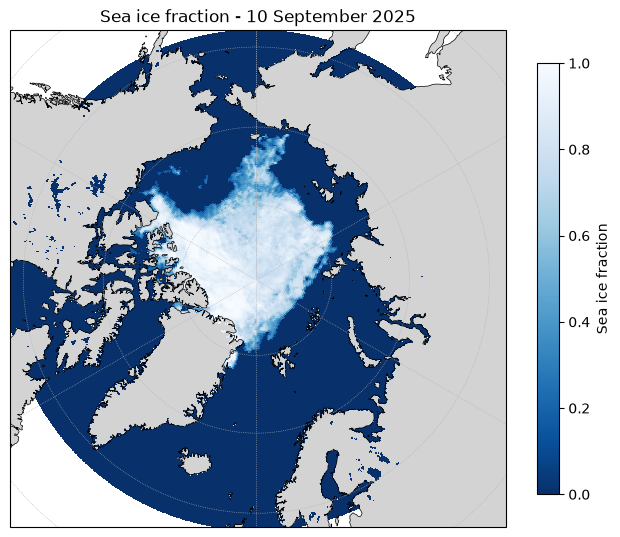

In [41]:
ice_fraction = minimum_data["sea_ice_fraction"].isel(time=0)

plot_arctic_map(
    ice_fraction,
    "Sea ice fraction - 10 September 2025",
    cmap="Blues_r", vmin=0, vmax=1,
    cbar_kwargs={"label": "Sea ice fraction", "shrink": 0.7},
)
plt.show()

At the 2025 minimum, the sea ice is limited to the central Arctic Ocean and the north of Greenland and of the Canadian Archipelago. Large areas along the coasts of Siberia and Alaska are free of ice.

<div class="alert alert-block alert-warning">

**Exercise 4**

Open the file of **22 March 2025** that you downloaded in exercise 3, and map its surface temperature and sea ice fraction, with the same colour scales as above.

How do the two dates compare? Where is the ice edge in March?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Use `xr.open_dataset` with the path of the file, then the same `plot_arctic_map` calls as above. To put two maps side by side, create the figure with `fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={"projection": ccrs.NorthPolarStereo()})` and pass `ax=axes[0]` and `ax=axes[1]` to `plot_arctic_map`.
</details>

In [ ]:

temperature = maximum_data["analysed_st"].isel(time=0)

missing_points = int(temperature.isnull().sum())
print(f"Missing values: {missing_points} of {temperature.size} grid points ({100 * missing_points / temperature.size:.0f}%)")
print(f"Temperature range: {float(temperature.min()):.1f} K to {float(temperature.max()):.1f} K")

NameError: name 'maximum_data' is not defined

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-01-get_exercise-4.py

> 📖 **Learn more in the Help Center:** [Open and visualize NetCDF files](https://help.marine.copernicus.eu/en/articles/4792430-open-and-visualize-netcdf-files)

---
# 6. Exercises to go further

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-info">

Here is a set of exercises to go further. There are two levels, depending on how much Python code you need to write. If you need help, do not hesitate to look at the [Help Center](https://help.marine.copernicus.eu/) or to contact the service desk: **[servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)**!

**Beginners**:

- Download the file of another day that interests you, for example the same day of a previous year, and compare the sea ice fraction.
- Each file also contains the variable `analysis_error`, the estimated error of the temperature. Map it: where is the analysis the least reliable, and why?

**Intermediate**:

- In a pattern, `[1-7]` matches a single character between 1 and 7. Use it to select the first week of September 2025 in a single `get` command, and check your selection with a dry run first.
- The `create_file_list` option writes the list of selected files to a text file, which can then be downloaded later with the `file_list` option. Try it, following the [Help Center article on get](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files).
- The Toolbox can also be used from the command line. Run the download of section 4.4 again with the command line, following the [command line version of the article](https://help.marine.copernicus.eu/en/articles/7983226-copernicus-marine-toolbox-cli-get-original-files).

</div>

---
# 7. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-success">
    <b>Congratulations !!</b><br>

And thank you for your attention! :)

In this notebook, you have learned to:

* Find a product and its datasets on the Copernicus Marine Data Store, and use its documentation
* Check a download before running it with the `dry_run` option
* Explore the object returned by `get`: number of files, sizes, names and paths
* Select and download original files with the `filter` option
* Open the files with xarray, check them, and map their variables

The `get` function is the right tool to download **whole original files**. When you only need a region, a period or a few variables, the `subset` function is much more efficient: this is the topic of the next notebook.

To go further, here are some Help Center articles:

* [Copernicus Marine Toolbox - Introduction](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction)
* [Toolbox API - Get original files](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files)
* [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset)
* [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely)
* [How to get data for a recurring period](https://help.marine.copernicus.eu/en/articles/7973161-how-to-get-data-for-a-recurring-period)
* [Toolbox FAQ](https://help.marine.copernicus.eu/en/articles/8630590-copernicus-marine-toolbox-faq) and [troubleshooting](https://help.marine.copernicus.eu/en/articles/8632322-copernicus-marine-toolbox-troubleshoots)
* [Copernicus Marine community and trainings](https://help.marine.copernicus.eu/en/collections/3740164-copernicus-marine-community-and-trainings)

This training course is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us at [servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)!
</div>